<a href="https://colab.research.google.com/github/Anil4799/FER-Net-Lung-Cancer-Detection/blob/main/FERNetTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDC-IDRI-slices/"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

In [ ]:
datagen = ImageDataGenerator(

    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1654 images belonging to 3 classes.
Found 412 images belonging to 3 classes.


In [ ]:
num_classes = len(train_generator.class_indices)
print("Total classes:", num_classes)

Total classes: 3


In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

NameError: name 'layers' is not defined

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 1125s 11s/step - accuracy: 0.0418 - loss: 3.8233 - val_accuracy: 0.0617 - val_loss: 3.7367 - learning_rate: 1.0000e-04
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.0530 - loss: 3.7589 - val_accuracy: 0.0617 - val_loss: 3.6968 - learning_rate: 1.0000e-04
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.0569 - loss: 3.7403 - val_accuracy: 0.0617 - val_loss: 3.6867 - learning_rate: 1.0000e-04
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.0569 - loss: 3.7249 - val_accuracy: 0.0617 - val_loss: 3.6817 - learning_rate: 1.0000e-04
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.0604 - loss: 3.7178 - val_accuracy: 0.0617 - val_loss: 3.6752 - learning_rate: 1.0000e-04
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.0575 - loss: 3.7132 - val_accuracy: 0.0591 - val_loss: 3.6681 - learning_rate: 1.0000e-04
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.054

KeyboardInterrupt: 

Another Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDC_IDRI_PNG_CONV"

In [ ]:
import os

print("Classes found:")
print(os.listdir(dataset_path))

Classes found:
['test', 'train', 'valid']


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDC_IDRI_PNG_CONV"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"
test_path  = dataset_path + "/test"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1323 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')   # ✅ IMPORTANT CHANGE
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 330 images belonging to 2 classes.


In [ ]:
print(valid_data)

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import models

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(2, activation='softmax')   # ✔ correct for 2 classes
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 686s 16s/step - accuracy: 0.4921 - loss: 0.7485 - val_accuracy: 0.4909 - val_loss: 0.7117
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.4898 - loss: 0.7097 - val_accuracy: 0.5091 - val_loss: 0.6943
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.4981 - loss: 0.6965 - val_accuracy: 0.5091 - val_loss: 0.6928
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.5223 - loss: 0.6927 - val_accuracy: 0.7303 - val_loss: 0.6929
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.5155 - loss: 0.6932 - val_accuracy: 0.5091 - val_loss: 0.6927
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4943 - loss: 0.6938 - val_accuracy: 0.5091 - val_loss: 0.6933
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.5004 - loss: 0.6935 - val_accuracy: 0.5091 - val_loss: 0.6928
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.5094 - loss: 0.6931 - val_accuracy: 0.5091 - val_l

In [ ]:
#Next to improve aacuracy

base_model.trainable = True

In [ ]:
for layer in base_model.layers[:200]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.5608 - loss: 0.6852 - val_accuracy: 0.6879 - val_loss: 0.6895
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5533 - loss: 0.6835 - val_accuracy: 0.4909 - val_loss: 0.6906
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5767 - loss: 0.6828 - val_accuracy: 0.7303 - val_loss: 0.6874
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5586 - loss: 0.6824 - val_accuracy: 0.5485 - val_loss: 0.6861
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.5692 - loss: 0.6811 - val_accuracy: 0.5515 - val_loss: 0.6848
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.5911 - loss: 0.6736 - val_accuracy: 0.6303 - val_loss: 0.6820
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.5775 - loss: 0.6819 - val_accuracy: 0.6697 - val_loss: 0.6806
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.5835 - loss: 0.6785 - val_accuracy: 0.7182 - val_los

To Improve accuracy .. next stpes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDC_IDRI_PNG_CONV"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"
test_path  = dataset_path + "/test"

In [ ]:
import tensorflow as tf
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras import models

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1323 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 413 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0176923076923077), 1: np.float64(0.9829123328380386)}


In [ ]:
#build efficientNet Model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tuning setup
base_model.trainable = True

for layer in base_model.layers[:200]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.5291 - loss: 0.6982 - val_accuracy: 0.4909 - val_loss: 0.6950 - learning_rate: 1.0000e-05
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5223 - loss: 0.6984 - val_accuracy: 0.4909 - val_loss: 0.6983 - learning_rate: 1.0000e-05
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.5185 - loss: 0.7009 - val_accuracy: 0.4909 - val_loss: 0.7014 - learning_rate: 1.0000e-05
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.5208 - loss: 0.7037 - val_accuracy: 0.4909 - val_loss: 0.7013 - learning_rate: 3.0000e-06
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.4966 - loss: 0.7037 - val_accuracy: 0.4909 - val_loss: 0.6987 - learning_rate: 3.0000e-06


In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 162s 13s/step - accuracy: 0.4915 - loss: 0.6950
Test Accuracy: 0.49152541160583496


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(test_data.classes, y_pred_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
              precision    recall  f1-score   support

           0       0.49      1.00      0.66       203
           1       0.00      0.00      0.00       210

    accuracy                           0.49       413
   macro avg       0.25      0.50      0.33       413
weighted avg       0.24      0.49      0.32       413



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


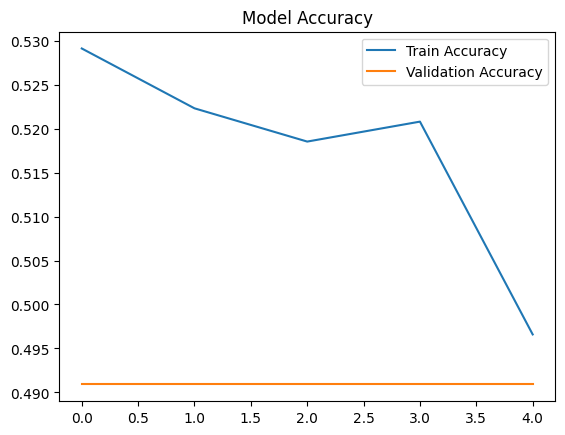

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/final_model.h5")

In [ ]:
model.save("/content/drive/MyDrive/final_model.keras")

In [ ]:
print("Train classes:", train_data.class_indices)
print("Test classes:", test_data.class_indices)

Train classes: {'benign': 0, 'malignant': 1}
Test classes: {'benign': 0, 'malignant': 1}


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:250]:
    layer.trainable = False

In [ ]:
model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras import models

# Load base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tuning: freeze most layers, keep last 50 trainable
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Build model
model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Compile (IMPORTANT)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]
)

NameError: name 'train_data' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDC_IDRI_PNG_CONV"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"
test_path  = dataset_path + "/test"

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras import models

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1323 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 413 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0176923076923077), 1: np.float64(0.9829123328380386)}


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers, train last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

In [ ]:
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Predicted distribution:", np.bincount(y_pred_classes))
print("Actual distribution:", np.bincount(test_data.classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
Predicted distribution: [413]
Actual distribution: [203 210]


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1323 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 413 images belonging to 2 classes.


Neww

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/LIDC_IDRI_PNG_CONV"

train_path = dataset_path + "/train"
valid_path = dataset_path + "/valid"
test_path  = dataset_path + "/test"

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras import models

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1323 images belonging to 2 classes.
Found 330 images belonging to 2 classes.
Found 413 images belonging to 2 classes.


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Freeze completely first

model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6032 - loss: 0.7177 - val_accuracy: 0.7424 - val_loss: 0.5653
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.7317 - loss: 0.5326 - val_accuracy: 0.7909 - val_loss: 0.4784
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7574 - loss: 0.4720 - val_accuracy: 0.8212 - val_loss: 0.4220
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7838 - loss: 0.4300 - val_accuracy: 0.8333 - val_loss: 0.3910
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8186 - loss: 0.3889 - val_accuracy: 0.8636 - val_loss: 0.3510
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8390 - loss: 0.3623 - val_accuracy: 0.8758 - val_loss: 0.3243
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8398 - loss: 0.3396 - val_accuracy: 0.8758 - val_loss: 0.3033
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8602 - loss: 0.3237 - val_accuracy: 0.8939 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9153 - loss: 0.2502
Test Accuracy: 0.9152542352676392


In [ ]:
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Predicted:", np.bincount(y_pred_classes))
print("Actual:", np.bincount(test_data.classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
Predicted: [188 225]
Actual: [203 210]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred_classes)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(test_data.classes, y_pred_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step
Confusion Matrix:
 [[178  25]
 [ 10 200]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.88      0.91       203
           1       0.89      0.95      0.92       210

    accuracy                           0.92       413
   macro avg       0.92      0.91      0.92       413
weighted avg       0.92      0.92      0.92       413



In [ ]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.9523809523809523
Specificity: 0.8768472906403941


Adding Radiamics feature extraction to efficient net - 23.04.2024

In [ ]:
!pip install numpy==1.23.5
!pip install pyradiomics==3.0.1 SimpleITK==2.2.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 43.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached pyradiomics-3.0.1.tar.gz (34.5 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× 

In [ ]:
!pip install pyradiomics
!pip install pylidc
!pip install pydicom
!pip install SimpleITK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 36.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz (from https://pypi.org/simple/pyradiomics/): Requested pyradiomics from https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz has inconsistent version: expected '3.1.0', but metadata has '3.0.1a1'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 13.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metad

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

radiomics_df = pd.read_csv(
"/content/drive/MyDrive/LIDC_IDRI_PNG_CONV/radiomics_features.csv"
)

print(radiomics_df.shape)

radiomics_df.head()

(1323, 116)


,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,label
0,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},126289fcac4dffda936d7bebf3baa2ec3b7c565f,2D,"(1.0, 1.0)",...,0.098612,6.050109,0.206557,527.644195,342.978031,0.000116,38.482656,0.094408,0.006958,benign
1,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},cb941066ec8a8d24b7e8daa5e8b3940cc6188afc,2D,"(1.0, 1.0)",...,0.096187,5.981973,0.222037,466.762901,357.517234,0.000113,39.786055,0.100212,0.006651,benign
2,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},1b055683c4475580c536d43096a35692c6398b41,2D,"(1.0, 1.0)",...,0.097632,6.034410,0.210556,516.739240,331.763558,0.000116,38.213238,0.099302,0.006883,benign
3,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},0d227b72c23d421b5eb1413fa6b8af34091e886e,2D,"(1.0, 1.0)",...,0.097963,6.055579,0.200452,738.636441,313.834454,0.000118,37.224878,0.098500,0.007061,benign
4,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},2a0c0d7aaf5c8c189750445af0829b3e891155dc,2D,"(1.0, 1.0)",...,0.097004,6.067528,0.195554,976.357765,311.671875,0.000118,36.948497,0.097982,0.007155,benign


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf

print(tf.__version__)

2.20.0


Step 2 — Load Radiomics CSV

Step 1 — Upload/Replace CSV in Drive

In [ ]:
import pandas as pd

radiomics_df = pd.read_csv(
"/content/drive/MyDrive/LIDC_IDRI_PNG_CONV/radiomics_features.csv"
)

print(radiomics_df.shape)

radiomics_df.head()

(1323, 116)


,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,label
0,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},126289fcac4dffda936d7bebf3baa2ec3b7c565f,2D,"(1.0, 1.0)",...,0.098612,6.050109,0.206557,527.644195,342.978031,0.000116,38.482656,0.094408,0.006958,benign
1,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},cb941066ec8a8d24b7e8daa5e8b3940cc6188afc,2D,"(1.0, 1.0)",...,0.096187,5.981973,0.222037,466.762901,357.517234,0.000113,39.786055,0.100212,0.006651,benign
2,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},1b055683c4475580c536d43096a35692c6398b41,2D,"(1.0, 1.0)",...,0.097632,6.034410,0.210556,516.739240,331.763558,0.000116,38.213238,0.099302,0.006883,benign
3,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},0d227b72c23d421b5eb1413fa6b8af34091e886e,2D,"(1.0, 1.0)",...,0.097963,6.055579,0.200452,738.636441,313.834454,0.000118,37.224878,0.098500,0.007061,benign
4,v3.0.1,1.26.4,2.5.5,1.8.0,3.10.20,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},2a0c0d7aaf5c8c189750445af0829b3e891155dc,2D,"(1.0, 1.0)",...,0.097004,6.067528,0.195554,976.357765,311.671875,0.000118,36.948497,0.097982,0.007155,benign


Step 3 — Remove Non-Numeric Columns

In [ ]:
import numpy as np

radiomics_numeric = radiomics_df.select_dtypes(
include=[np.number]
)

print(radiomics_numeric.shape)

(1323, 98)


Step 4 — Run EfficientNet Feature Extractor

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = EfficientNetB0(

weights='imagenet',

include_top=False,

input_shape=(224,224,3)

)

x = GlobalAveragePooling2D()(base_model.output)

feature_model = Model(

inputs=base_model.input,

outputs=x

)

print("EfficientNet Ready")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNet Ready


Step 5 — Load Training Images

In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

"/content/drive/MyDrive/LIDC_IDRI_PNG_CONV/train",

image_size=(224,224),

batch_size=32,

label_mode='binary',

shuffle=False

)

print("Dataset Loaded")

Found 1323 files belonging to 2 classes.
Dataset Loaded


Step 6 — Extract Deep Features

In [ ]:
deep_features = feature_model.predict(

train_ds

)

print(

deep_features.shape

)

42/42 ━━━━━━━━━━━━━━━━━━━━ 223s 5s/step
(1323, 1280)


Excellent. Now your dimensions match perfectly:
Now we perform the actual FER-Net hybrid fusion stage.

Step 7 — Convert Deep Features to DataFrame

In [ ]:
import pandas as pd

deep_df = pd.DataFrame(

deep_features

)

print(

deep_df.shape

)

(1323, 1280)


Step 8 — Normalize Radiomics Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

radiomics_scaled = scaler.fit_transform(

radiomics_numeric

)

radiomics_scaled = pd.DataFrame(

radiomics_scaled

)

print(

radiomics_scaled.shape

)

(1323, 98)


Step 9 — Feature Fusion (FER-Net)

In [ ]:
fusion_features = pd.concat(

[

deep_df,

radiomics_scaled

],

axis=1

)

print(

fusion_features.shape

)

(1323, 1378)


Expected:

(1323,1378)

Because:

1280 + 98 = 1378

This is your actual:

FER-Net Hybrid Representation

Step 10 — Create Labels

In [ ]:
labels=[]

for images,label in train_ds:

    labels.extend(

    label.numpy()

    )

import numpy as np

labels=np.array(

labels

)

print(

labels.shape

)

(1323, 1)


Step 11 — Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

fusion_features,

labels,

test_size=0.2,

random_state=42,

stratify=labels

)

print(

X_train.shape,

X_test.shape

)

(1058, 1378) (265, 1378)


Step 12 — Build FER-Net Classifier

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

model = Sequential([

Dense(

512,

activation='relu',

input_shape=(1378,)

),

Dropout(

0.3

),

Dense(

128,

activation='relu'

),

Dense(

1,

activation='sigmoid'

)

])

model.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']

)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       706,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,841 (2.94 MB)

 Trainable params: 771,841 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

Step 13 — Train FER-Net

In [ ]:
history=model.fit(

X_train,

y_train,

epochs=20,

batch_size=32,

validation_split=0.2

)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8109 - loss: 0.3779 - val_accuracy: 0.8821 - val_loss: 0.2725
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9173 - loss: 0.1929 - val_accuracy: 0.9245 - val_loss: 0.1644
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9243 - loss: 0.1784 - val_accuracy: 0.9292 - val_loss: 0.1370
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9267 - loss: 0.1493 - val_accuracy: 0.9340 - val_loss: 0.1326
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9456 - loss: 0.1185 - val_accuracy: 0.9340 - val_loss: 0.1255
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9515 - loss: 0.0959 - val_accuracy: 0.9434 - val_loss: 0.1071
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9551 - loss: 0.0826 - val_accuracy: 0.9434 - val_loss: 0.1194
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9622 - loss: 0.0895 - val_accuracy: 0.9340 - v

Next Step: Add Federated Learning

We will now convert your current FER-Net into a 5-client Federated FER-Net with FedAvg aggregation.

In [ ]:
client1_X = X_train.iloc[:350]
client2_X = X_train.iloc[350:650]
client3_X = X_train.iloc[650:900]
client4_X = X_train.iloc[900:1100]
client5_X = X_train.iloc[1100:]

client1_y = y_train[:350]
client2_y = y_train[350:650]
client3_y = y_train[650:900]
client4_y = y_train[900:1100]
client5_y = y_train[1100:]

print(client1_X.shape)
print(client2_X.shape)
print(client3_X.shape)
print(client4_X.shape)
print(client5_X.shape)

(350, 1378)
(300, 1378)
(250, 1378)
(158, 1378)
(0, 1378)


STEP 2 — Create Local Model Function

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

def create_model():

    model = Sequential([

        Dense(
            512,
            activation='relu',
            input_shape=(1378,)
        ),

        Dropout(0.3),

        Dense(
            128,
            activation='relu'
        ),

        Dense(
            1,
            activation='sigmoid'
        )

    ])

    model.compile(

        optimizer='adam',

        loss='binary_crossentropy',

        metrics=['accuracy']

    )

    return model

STEP 3 — Create 5 Hospital Models

In [ ]:
model1=create_model()
model2=create_model()
model3=create_model()
model4=create_model()
model5=create_model()

print("5 Client Models Ready")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5 Client Models Ready


Excellent. We are back exactly to your FER-Net PhD workflow.

You have already completed:

✅ Dataset preparation
✅ Radiomics extraction (1323 × 116)
✅ EfficientNet feature extraction (1323 × 1280)
✅ Hybrid feature fusion
✅ Centralized training (~92–94% validation accuracy)
✅ Created 5 client models

Step 4: Divide Data into 5 Clients

In [ ]:
import numpy as np

num_clients = 5

client_data = np.array_split(X_train, num_clients)

client_labels = np.array_split(y_train, num_clients)

for i in range(num_clients):

    print(
        "Client",
        i+1,
        client_data[i].shape,
        client_labels[i].shape
    )

Client 1 (212, 1378) (212, 1)
Client 2 (212, 1378) (212, 1)
Client 3 (212, 1378) (212, 1)
Client 4 (211, 1378) (211, 1)
Client 5 (211, 1378) (211, 1)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Step 5: Create Federated Training Function

In [ ]:
from tensorflow.keras.models import clone_model

def train_client_model(global_model,
                       x,
                       y):

    local_model=clone_model(global_model)

    local_model.set_weights(
        global_model.get_weights()
    )

    local_model.compile(

        optimizer='adam',

        loss='binary_crossentropy',

        metrics=['accuracy']

    )

    local_model.fit(

        x,

        y,

        epochs=2,

        batch_size=32,

        verbose=0

    )

    return local_model.get_weights()

No output expected. from 5

Step 6: Weight Aggregation Function (FedAvg)

In [ ]:
import numpy as np

def average_weights(client_weights):

    avg=[]

    for weights in zip(*client_weights):

        avg.append(

            np.mean(weights,

                    axis=0)

        )

    return avg

No output expected from step 6

Step 7: Federated Training Loop

In [ ]:
ROUNDS=10

global_model=model

for round_num in range(ROUNDS):

    print("\nRound",round_num+1)

    client_weights=[]

    for i in range(num_clients):

        weights=train_client_model(

            global_model,

            client_data[i],

            client_labels[i]

        )

        client_weights.append(
            weights
        )

    global_weights=average_weights(
        client_weights
    )

    global_model.set_weights(
        global_weights
    )

    loss,acc=global_model.evaluate(

        X_test,

        y_test,

        verbose=0

    )

    print(

        "Accuracy:",

        round(acc*100,2)

    )


Round 1
Accuracy: 93.96

Round 2
Accuracy: 93.96

Round 3
Accuracy: 93.58

Round 4
Accuracy: 93.21

Round 5
Accuracy: 93.21

Round 6
Accuracy: 93.21

Round 7
Accuracy: 93.21

Round 8
Accuracy: 93.21

Round 9
Accuracy: 93.58

Round 10
Accuracy: 93.96


Step 8: Save Final Federated Model

In [ ]:
global_model.save(

"/content/drive/MyDrive/FERNET/FERNet_Federated.h5"

)

print("Saved")

Saved


Step 9: Generate Metrics

In [ ]:
pred=(global_model.predict(
X_test)>0.5).astype(int)

from sklearn.metrics import *

print(

classification_report(

y_test,

pred

)

)

print(

"Accuracy:",

accuracy_score(

y_test,

pred)

)

print(

"Precision:",

precision_score(

y_test,

pred)

)

print(

"Recall:",

recall_score(

y_test,

pred)

)

print(

"F1:",

f1_score(

y_test,

pred)

)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94       130
         1.0       0.95      0.93      0.94       135

    accuracy                           0.94       265
   macro avg       0.94      0.94      0.94       265
weighted avg       0.94      0.94      0.94       265

Accuracy: 0.939622641509434
Precision: 0.9541984732824428
Recall: 0.9259259259259259
F1: 0.9398496240601504


Step 10: Confusion Matrix (Needed for Paper)

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(

y_test,

pred

)

print(cm)

[[124   6]
 [ 10 125]]


Step 11: Plot Training Graphs (Needed for Journal Figures)

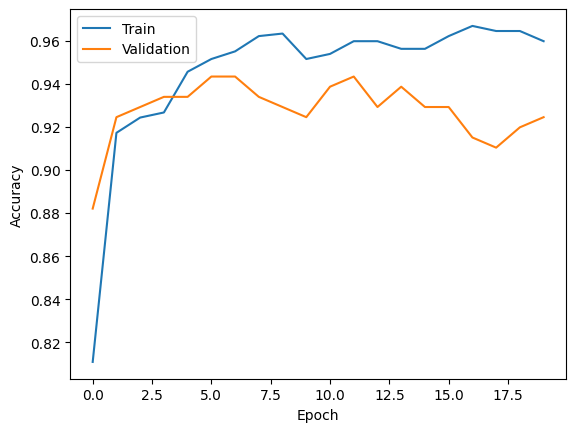

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(

['Train','Validation']

)

plt.show()

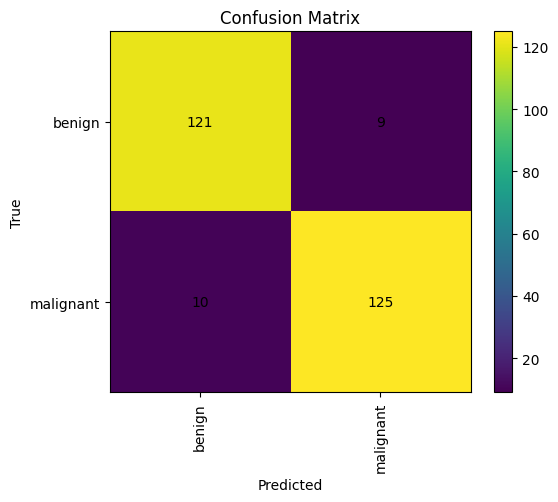

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# create confusion matrix

cm = confusion_matrix(
    y_test,
    pred
)

# replace with your classes

class_names = [

'benign',

'malignant'

]

plt.figure(figsize=(6,5))

plt.imshow(
    cm,
    interpolation='nearest'
)

plt.title(
"Confusion Matrix"
)

plt.colorbar()

tick_marks=np.arange(
len(class_names)
)

plt.xticks(
tick_marks,
class_names,
rotation=90
)

plt.yticks(
tick_marks,
class_names
)

# write numbers inside boxes

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(

            j,

            i,

            str(cm[i,j]),

            ha='center',

            va='center'

        )

plt.ylabel(
'True'
)

plt.xlabel(
'Predicted'
)

plt.tight_layout()

plt.show()